<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/04.quantum-kernel-classification/01.iris-qsvm/22_qsvm_performance_analysis_improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day27 QSVM 성능 분석과 개선 전략 실습

- Source: Google Drive `Day27/4-2.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Library Import

STEP 2. Load Previous Result
Previous Result Loaded

STEP 3. Performance Metrics
Accuracy           : 0.8667
Correct Prediction : 26
Wrong Prediction   : 4
Total Samples      : 30

STEP 4. Classification Report
{'0': {'precision': 1.0, 'recall': 0.7333333333333333, 'f1-score': 0.8461538461538461, 'support': 15.0}, '1': {'precision': 0.7894736842105263, 'recall': 1.0, 'f1-score': 0.8823529411764706, 'support': 15.0}, 'accuracy': 0.8666666666666667, 'macro avg': {'precision': 0.8947368421052632, 'recall': 0.8666666666666667, 'f1-score': 0.8642533936651584, 'support': 30.0}, 'weighted avg': {'precision': 0.8947368421052633, 'recall': 0.8666666666666667, 'f1-score': 0.8642533936651584, 'support': 30.0}}

STEP 5. Confusion Matrix
[[11  4]
 [ 0 15]]

STEP 6. Confusion Matrix Heatmap


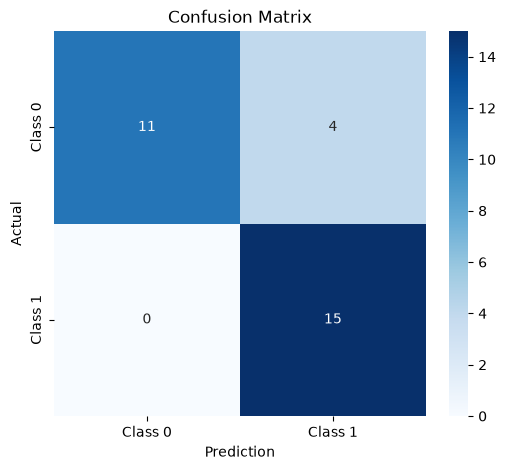


STEP 7. Wrong Prediction
Wrong Sample Count : 4

Index : 1
True Label : 0
Prediction : 1
----------------------------------------
Index : 3
True Label : 0
Prediction : 1
----------------------------------------
Index : 16
True Label : 0
Prediction : 1
----------------------------------------
Index : 25
True Label : 0
Prediction : 1
----------------------------------------

STEP 8. Error Analysis

학생들이 아래 내용을 분석한다.

□ Feature가 경계 부근인가?

□ Noise가 존재하는가?

□ 두 클래스가 유사한가?

□ False Positive가 많은가?

□ False Negative가 많은가?

□ Recall이 낮은 이유는 무엇인가?

□ Precision이 낮은 이유는 무엇인가?


STEP 9. Classical SVM vs QSVM
      Metric  Classical SVM      QSVM
0   Accuracy            1.0  0.866667
1  Precision            1.0  0.789474
2     Recall            1.0  1.000000
3   F1 Score            1.0  0.882353
      Metric  Classical SVM      QSVM
0   Accuracy            1.0  0.866667
1  Precision            1.0  0.789474
2     Recall            1.0  1.000000
3   F1 Score            1.0  0.882353

STEP 10. Quantu

In [1]:
"""
==========================================================
 Lab QSVM Performance Analysis & Improvement Strategy
==========================================================

실습 목표

1. 기존 QSVM 평가 결과를 분석한다.
2. Classification Report를 해석한다.
3. Confusion Matrix를 분석한다.
4. 오분류 데이터를 확인한다.
5. Classical SVM과 비교한다.
6. Quantum Advantage를 평가한다.
7. 개선 전략을 수립한다.

※ 이번 실습은 모델을 다시 학습하지 않는다.
※ 앞선 실습에서 생성한 결과(Result)를 그대로 사용한다.
"""

# ==========================================================
# STEP 1. Library Import
# ==========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report


print("="*60)
print("STEP 1. Library Import")
print("="*60)



# ==========================================================
# STEP 2. 이전 실습 결과(Result) 준비
# ==========================================================



import pickle
import os
import numpy as np

OUTPUT_DIR = "./output"
CLASSICAL_DIR = "./output/classical"

print("\n"+"="*60)
print("STEP 2. Load Previous Result")
print("="*60)

with open(
    os.path.join(OUTPUT_DIR,"accuracy_info.pkl"),
    "rb"
) as f:

    accuracy_info = pickle.load(f)

with open(
    os.path.join(OUTPUT_DIR,"metric_info.pkl"),
    "rb"
) as f:

    metric_info = pickle.load(f)

with open(
    os.path.join(
        OUTPUT_DIR,
        "classification_report.pkl"
    ),
    "rb"
) as f:

    report = pickle.load(f)

with open(
    os.path.join(OUTPUT_DIR, "confusion_matrix.pkl"),
    "rb"
) as f:

    cm_info = pickle.load(f)

cm = np.array([
    [cm_info["TN"], cm_info["FP"]],
    [cm_info["FN"], cm_info["TP"]]
])

with open(
    os.path.join(
        OUTPUT_DIR,
        "prediction_info.pkl"
    ),
    "rb"
) as f:

    prediction = pickle.load(f)

with open(
    os.path.join(
        OUTPUT_DIR,
        "roc_info.pkl"
    ),
    "rb"
) as f:

    roc_info = pickle.load(f)

X_test = np.load(
    os.path.join(
        OUTPUT_DIR,
        "X_test.npy"
    )
)

y_test = np.load(
    os.path.join(
        OUTPUT_DIR,
        "y_test.npy"
    )
)

y_pred = np.load(
    os.path.join(
        OUTPUT_DIR,
        "y_prediction.npy"
    )
)

y_score = np.load(
    os.path.join(
        OUTPUT_DIR,
        "y_score.npy"
    )
)

with open(
    os.path.join(CLASSICAL_DIR, "metric_info.pkl"),
    "rb"
) as f:

    classical_metric = pickle.load(f)

accuracy = metric_info["accuracy"]

precision = metric_info["precision"]

recall = metric_info["recall"]

f1 = metric_info["f1_score"]





print("Previous Result Loaded")

# ==========================================================
# STEP 3. Performance Metrics
# ==========================================================

print("\n" + "=" * 60)
print("STEP 3. Performance Metrics")
print("=" * 60)

print(f"Accuracy           : {accuracy_info['accuracy']:.4f}")
print(f"Correct Prediction : {accuracy_info['correct_prediction']}")
print(f"Wrong Prediction   : {accuracy_info['wrong_prediction']}")
print(f"Total Samples      : {accuracy_info['total_samples']}")

# ==========================================================
# STEP 4. Classification Report
# ==========================================================

print("\n"+"="*60)
print("STEP 4. Classification Report")
print("="*60)

print(report)

# ==========================================================
# STEP 5. Confusion Matrix
# ==========================================================

print("\n"+"="*60)
print("STEP 5. Confusion Matrix")
print("="*60)

print(cm)

# ==========================================================
# STEP 6. Heatmap
# ==========================================================

print("\n"+"="*60)
print("STEP 6. Confusion Matrix Heatmap")
print("="*60)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0","Class 1"],
    yticklabels=["Class 0","Class 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# STEP 7. Wrong Prediction
# ==========================================================

print("\n"+"="*60)
print("STEP 7. Wrong Prediction")
print("="*60)

wrong_index = np.where(y_test != y_pred)[0]

print("Wrong Sample Count :", len(wrong_index))

print()

for idx in wrong_index:

    print(f"Index : {idx}")

    print(f"True Label : {y_test[idx]}")

    print(f"Prediction : {y_pred[idx]}")

    print("-"*40)

# ==========================================================
# STEP 8. Error Analysis
# ==========================================================

print("\n"+"="*60)
print("STEP 8. Error Analysis")
print("="*60)

print("""
학생들이 아래 내용을 분석한다.

□ Feature가 경계 부근인가?

□ Noise가 존재하는가?

□ 두 클래스가 유사한가?

□ False Positive가 많은가?

□ False Negative가 많은가?

□ Recall이 낮은 이유는 무엇인가?

□ Precision이 낮은 이유는 무엇인가?
""")

# ==========================================================
# STEP 9. Classical vs QSVM
# ==========================================================

print("\n" + "=" * 60)
print("STEP 9. Classical SVM vs QSVM")
print("=" * 60)

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Classical SVM":[

        classical_metric["accuracy"],

        classical_metric["precision"],

        classical_metric["recall"],

        classical_metric["f1"]

    ],

    "QSVM":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

print(comparison)

print(comparison)

# ==========================================================
# STEP 10. Quantum Advantage
# ==========================================================

print("\n" + "=" * 60)
print("STEP 10. Quantum Advantage")
print("=" * 60)

if accuracy > classical_metric["accuracy"]:

    print("✓ Accuracy 기준으로 QSVM이 우수합니다.")

elif accuracy < classical_metric["accuracy"]:

    print("✓ Accuracy 기준으로 Classical SVM이 우수합니다.")

else:

    print("✓ Accuracy는 동일합니다.")

print()

print("Quantum Advantage Checklist")

print("--------------------------")

print("□ Accuracy")

print("□ Precision")

print("□ Recall")

print("□ F1 Score")

print("□ Training Time")

print("□ Computational Cost")

print("□ Quantum Resource")

print()

print("※ Quantum Advantage는 Accuracy만으로 판단하지 않습니다.")

# ==========================================================
# STEP 11. Improvement Checklist
# ==========================================================

print("\n"+"="*60)
print("STEP 11. Improvement Checklist")
print("="*60)

checklist = [

    "□ Data 증가",

    "□ Feature 선택 변경",

    "□ Feature Scaling 변경",

    "□ Feature Map 변경",

    "□ Kernel 변경",

    "□ SVM Parameter 변경",

    "□ Class Weight 조정",

    "□ Shots 증가",

    "□ Noise Model 적용",

    "□ Hardware 테스트"

]

for item in checklist:

    print(item)

# ==========================================================
# STEP 12. Performance Report
# ==========================================================

print("\n"+"="*60)
print("STEP 12. Final Performance Report")
print("="*60)

print(f"""
==============================
        QSVM REPORT
==============================

Accuracy  : {accuracy:.4f}

Precision : {precision:.4f}

Recall    : {recall:.4f}

F1 Score  : {f1:.4f}

Wrong Samples : {len(wrong_index)}

==============================
Improvement Strategy

1. Data 확인

2. Feature 개선

3. Feature Map 개선

4. Kernel 개선

5. Parameter 조정

6. Hardware 검증

==============================
Quantum Advantage

Performance

+

Cost

+

Scalability

를 함께 평가해야 한다.
==============================
""")




